In [1]:
from itertools import product
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.inference.CausalInference import CausalInference
import networkx as nx
import matplotlib.pyplot as plt

INFO:numexpr.utils:Note: NumExpr detected 12 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
INFO:numexpr.utils:NumExpr defaulting to 8 threads.


In [2]:
def build_lagged_dag(variables, max_lag, relations):
    nodes = [
        f"{v}_t" if lag == 0 else f"{v}_t-{lag}"
        for v, lag in product(variables, range(max_lag + 1))
    ]

    edges = []
    for source, lag_offset, target in relations:

        for shift in range(max_lag - lag_offset + 1):

            src_lag = lag_offset + shift
            tgt_lag = shift

            src = f"{source}_t-{src_lag}"
            tgt = f"{target}_t" if tgt_lag == 0 else f"{target}_t-{tgt_lag}"

            edges.append((src, tgt))

    model = DiscreteBayesianNetwork()
    model.add_nodes_from(nodes)
    model.add_edges_from(edges)

    return model

In [3]:
variables = ["A", "P", "M", "D"]
max_lag = 7

relations = [
    ## X_t-y --> Z_t
    ("P",1,"A"),
    ("A",1,"P"),
    ("P",7,"D"),
    ("A",1,"M"),
    ("P",1,"M"),
    ("M",4,"P"),
    ("M",1,"P"),
    ("M",7,"D"),
    ("D",7,"M"),
]


model = build_lagged_dag(variables, max_lag, relations)

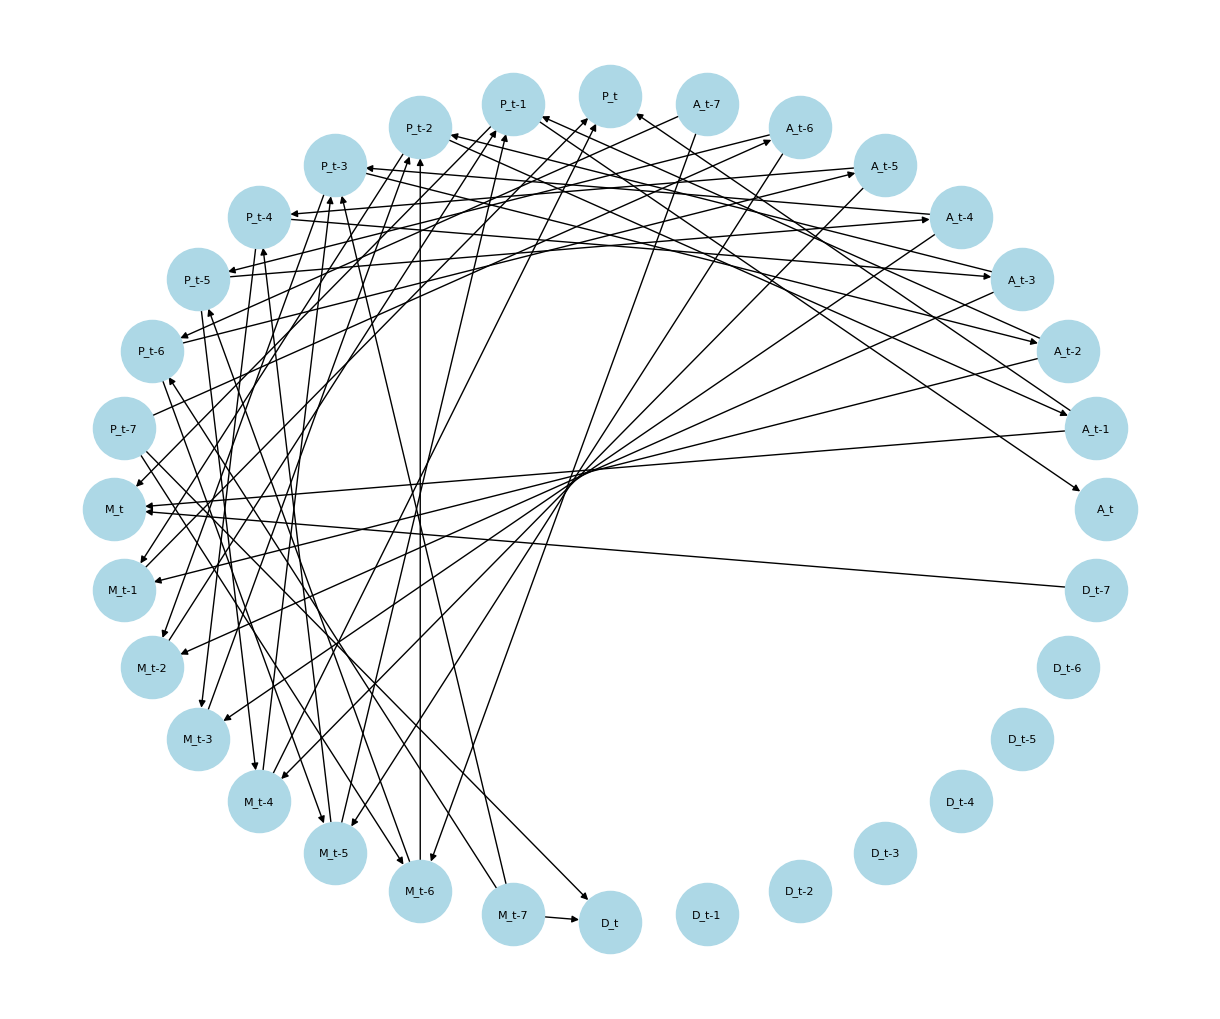

In [4]:
G = nx.DiGraph()
G.add_nodes_from(model.nodes())
G.add_edges_from(model.edges())

plt.figure(figsize=(12,10))
nx.draw_circular(
    G,
    with_labels=True,
    node_size=2000,
    node_color="lightblue",
    arrows=True,
    font_size=8
)

plt.show()

In [5]:
ci = CausalInference(model)

adj_sets = ci.get_minimal_adjustment_set(
    ## causal effect from x to y
    X="A_t-4",
    Y="D_t"
)

print("Adjustment sets:", adj_sets)

Adjustment sets: {'P_t-7'}
